In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats/cookie_cats.csv


# Cookie Cats A/B Test Analysis

## 1. Project Background

Cookie Cats is a mobile puzzle game.  
In this A/B test, the company changed the position of the first gate from level 30 to level 40.

- **Control Group:** gate_30
- **Treatment Group:** gate_40

The goal of this project is to evaluate whether moving the gate from level 30 to level 40 improves user retention.

## 2. Business Question

Does moving the first gate from level 30 to level 40 significantly improve player retention?

## 3. Key Metrics

This project focuses on:

- Number of game rounds
- 1-day retention
- 7-day retention
- Difference between A/B groups

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## 4. Load Dataset

First, we load the Cookie Cats A/B testing dataset and check the basic structure.

In [5]:
df = pd.read_csv('/kaggle/input/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats/cookie_cats.csv')

df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [7]:
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


## 5. Data Understanding

The dataset contains user-level experimental data.

Main columns:

- `userid`: unique player ID
- `version`: experiment group
- `sum_gamerounds`: total game rounds played
- `retention_1`: whether the user returned after 1 day
- `retention_7`: whether the user returned after 7 days

In [8]:
df.isnull().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## 6. Group Size Check

Before analyzing the experiment results, we need to check whether the two groups are balanced.

In [10]:
df['version'].value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

In [11]:
df['version'].value_counts(normalize=True)

version
gate_40    0.504374
gate_30    0.495626
Name: proportion, dtype: float64

### Initial Observation

The dataset has no missing values.  
The two experiment groups are close in size, which means the A/B test design is relatively balanced.

## 7. Exploratory Data Analysis (EDA)

In this section, we explore player behavior and compare the distributions between the two experiment groups.

In [12]:
df['sum_gamerounds'].describe()

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

### Observation

Most players played only a small number of rounds, while a few players played extremely large numbers of rounds.

This indicates that the dataset may contain outliers.

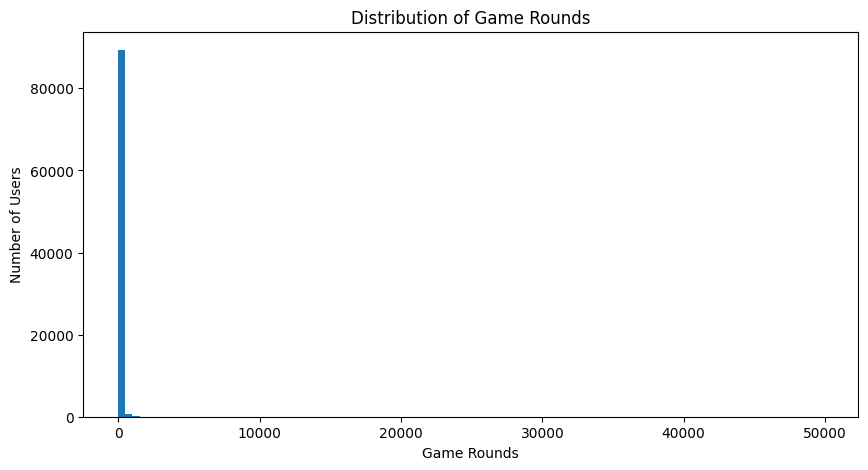

In [13]:
plt.figure(figsize=(10,5))

plt.hist(df['sum_gamerounds'], bins=100)

plt.xlabel('Game Rounds')
plt.ylabel('Number of Users')
plt.title('Distribution of Game Rounds')

plt.show()

## 8. Outlier Detection

Some players have extremely high game rounds, which may affect the analysis.

We remove extreme outliers to better understand normal player behavior.

In [15]:
df['sum_gamerounds'].max()

49854

In [17]:
df[df['sum_gamerounds'] > 40000]

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True


In [18]:
df = df[df['sum_gamerounds'] < 40000]

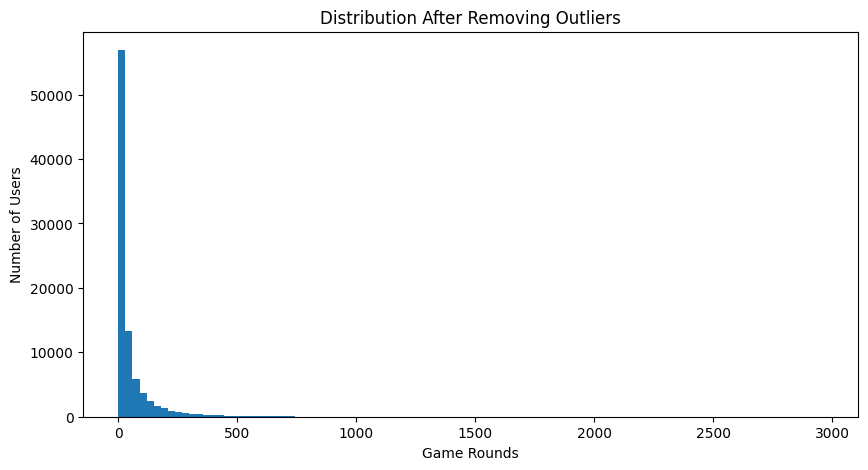

In [19]:
plt.figure(figsize=(10,5))

plt.hist(df['sum_gamerounds'], bins=100)

plt.xlabel('Game Rounds')
plt.ylabel('Number of Users')
plt.title('Distribution After Removing Outliers')

plt.show()

### Observation After Removing Outliers

After removing extreme outliers, the distribution becomes more interpretable.

Most users still play relatively few rounds, while only a small portion of users are highly engaged.

## 9. Retention Analysis

Next, we compare retention rates between the two experiment groups.

In [20]:
retention_1 = df.groupby('version')['retention_1'].mean()

retention_1

version
gate_30    0.448198
gate_40    0.442283
Name: retention_1, dtype: float64

In [21]:
retention_7 = df.groupby('version')['retention_7'].mean()

retention_7

version
gate_30    0.190183
gate_40    0.182000
Name: retention_7, dtype: float64

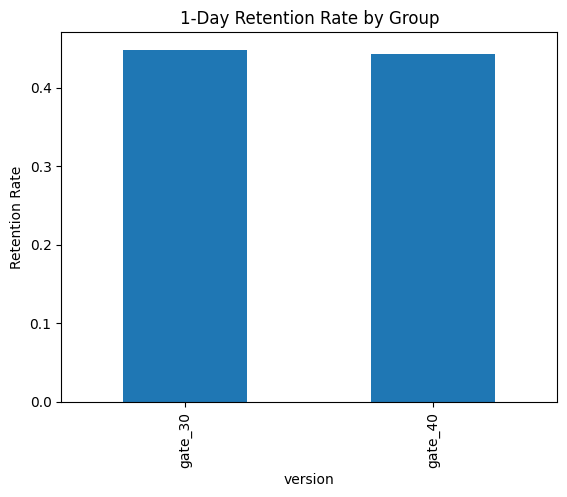

In [22]:
retention_1.plot(kind='bar')

plt.ylabel('Retention Rate')
plt.title('1-Day Retention Rate by Group')

plt.show()

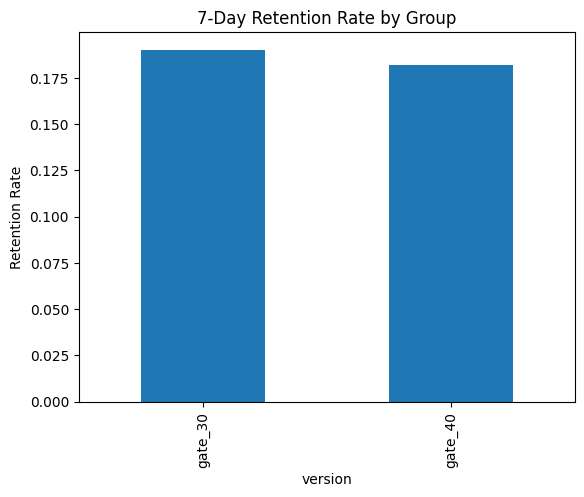

In [23]:
retention_7.plot(kind='bar')

plt.ylabel('Retention Rate')
plt.title('7-Day Retention Rate by Group')

plt.show()

### Initial Retention Findings

The retention rates between the two groups appear slightly different.

However, visual differences alone are not enough to conclude statistical significance.

Next, we will conduct hypothesis testing.

## 10. Hypothesis Testing

Visual differences are not sufficient to determine whether the experiment result is statistically significant.

We will conduct statistical hypothesis testing to evaluate whether the retention differences between the two groups are significant.

### 10.1 1-Day Retention Hypothesis Test

#### Null Hypothesis (H0)

There is no difference in 1-day retention between gate_30 and gate_40.

#### Alternative Hypothesis (H1)

There is a significant difference in 1-day retention between the two groups.

In [24]:
gate_30 = df[df['version'] == 'gate_30']['retention_1']
gate_40 = df[df['version'] == 'gate_40']['retention_1']

In [25]:
from statsmodels.stats.proportion import proportions_ztest

success = [
    gate_30.sum(),
    gate_40.sum()
]

nobs = [
    gate_30.count(),
    gate_40.count()
]

z_stat, p_value = proportions_ztest(success, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 1.787103509763628
P-value: 0.0739207603418346


### 1-Day Retention Test Result

If the p-value is smaller than 0.05, we reject the null hypothesis and conclude that the difference is statistically significant.

Otherwise, we fail to reject the null hypothesis.

In [26]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("The difference is statistically significant.")
else:
    print("Fail to reject the null hypothesis.")
    print("The difference is NOT statistically significant.")

Fail to reject the null hypothesis.
The difference is NOT statistically significant.


### 10.2 7-Day Retention Hypothesis Test

Next, we test whether the difference in 7-day retention is statistically significant.

In [31]:
gate_30_7 = df[df['version'] == 'gate_30']['retention_7']
gate_40_7 = df[df['version'] == 'gate_40']['retention_7']

In [32]:
success_7 = [
    gate_30_7.sum(),
    gate_40_7.sum()
]

nobs_7 = [
    gate_30_7.count(),
    gate_40_7.count()
]

z_stat_7, p_value_7 = proportions_ztest(success_7, nobs_7)

print("Z-statistic:", z_stat_7)
print("P-value:", p_value_7)

Z-statistic: 3.1574100858819936
P-value: 0.0015917731773993442


In [33]:
if p_value_7 < alpha:
    print("Reject the null hypothesis.")
    print("The difference is statistically significant.")
else:
    print("Fail to reject the null hypothesis.")
    print("The difference is NOT statistically significant.")

Reject the null hypothesis.
The difference is statistically significant.


## 11. Business Conclusion

The analysis shows that moving the gate from level 30 to level 40 did not improve player retention.

In fact, the gate_30 group achieved slightly higher retention rates in both 1-day and 7-day retention metrics.

This suggests that earlier gameplay challenges may help maintain player engagement and long-term retention.

Therefore, keeping the gate at level 30 may be a better business decision for the game.

## 12. Key Takeaways

- Conducted a complete A/B testing analysis using real-world gaming data
- Performed data cleaning, exploratory data analysis, and visualization
- Applied statistical hypothesis testing using Z-test
- Evaluated player retention behavior from a business perspective
- Generated actionable business insights based on experiment results

## 13. Bootstrap Analysis

To further validate the experiment results, we apply bootstrap resampling.

Bootstrap helps estimate the uncertainty of retention differences by repeatedly sampling the data.

In [34]:
retention_diff = (
    retention_7['gate_30']
    - retention_7['gate_40']
)

retention_diff

np.float64(0.00818318160884296)

In [35]:
boot_diffs = []

for i in range(5000):

    boot_30 = gate_30_7.sample(
        frac=1,
        replace=True
    ).mean()

    boot_40 = gate_40_7.sample(
        frac=1,
        replace=True
    ).mean()

    boot_diffs.append(boot_30 - boot_40)

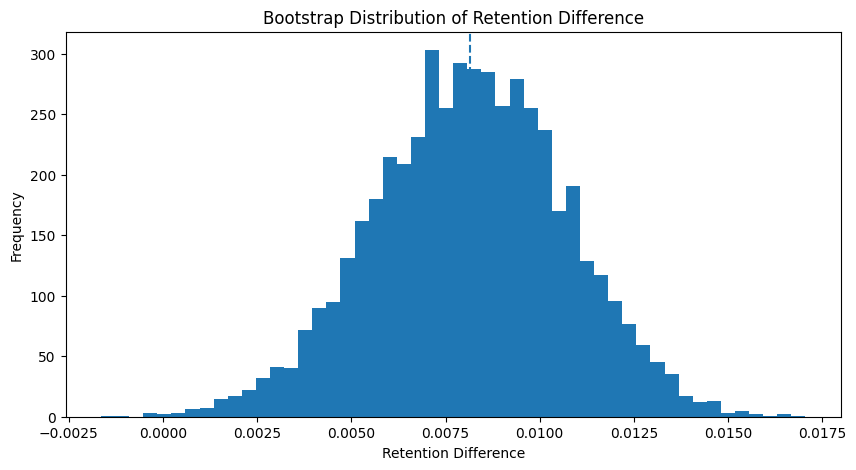

In [36]:
plt.figure(figsize=(10,5))

plt.hist(boot_diffs, bins=50)

plt.axvline(
    np.mean(boot_diffs),
    linestyle='--'
)

plt.title('Bootstrap Distribution of Retention Difference')
plt.xlabel('Retention Difference')
plt.ylabel('Frequency')

plt.show()

## 14. Confidence Interval

Next, we calculate the 95% confidence interval of the retention difference.

In [37]:
lower = np.percentile(boot_diffs, 2.5)
upper = np.percentile(boot_diffs, 97.5)

print("95% Confidence Interval:")
print(lower, upper)

95% Confidence Interval:
0.003046656171882062 0.013048354196397181


### Confidence Interval Interpretation

If the confidence interval does not include 0, the difference is likely statistically significant.

This provides additional evidence supporting the experiment result.

# 15. Final Business Insights

The experiment indicates that moving the first gate from level 30 to level 40 negatively impacted long-term player retention.

Although the short-term (1-day) retention difference was not statistically significant, the 7-day retention analysis showed a significant decline in the gate_40 group.

This suggests that delaying gameplay friction may reduce player engagement and weaken long-term retention behavior.

From a product and game design perspective, introducing moderate challenges earlier in the user journey may help strengthen habit formation and long-term engagement.

Therefore, maintaining the original gate_30 design appears to be the better business decision.

# 16. Project Summary

In this project, I conducted a complete A/B testing analysis using real-world gaming experiment data.

The workflow included:

- Data cleaning and preprocessing
- Exploratory data analysis (EDA)
- Outlier detection
- Retention analysis
- Statistical hypothesis testing
- Bootstrap resampling
- Confidence interval estimation
- Business insight generation

This project demonstrates practical skills in product analytics, experimentation analysis, and data-driven decision making.